## Task 3: Power Consumption Forecasting

In [1]:
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    RepeatVector,
    Concatenate
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


In [2]:
# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

HISTORY_HOURS = 168       # Previous 7 days
FORECAST_HORIZON = 24     # Next 24 hours
TEST_DAYS = 7

BATCH_SIZE = 32
EPOCHS = 100

ROOT = (
    Path(__file__).resolve().parents[1]
    if "__file__" in globals()
    else Path.cwd().parent
)

DATA = ROOT / "data"
FIG = ROOT / "figures"
MODELS = ROOT / "models"

FIG.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

print("=" * 70)
print("TASK 3 - LSTM ENERGY CONSUMPTION FORECASTING")
print("=" * 70)

print("\nLoading telemetry data...")

telem = pd.read_csv(
    DATA / "sensor_telemetry.csv",
    parse_dates=["timestamp"]
)

print(f"Raw records: {len(telem):,}")

required_columns = [
    "timestamp",
    "building_id",
    "asset_id",
    "power_consumption"
]

missing_columns = [
    col for col in required_columns
    if col not in telem.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

TASK 3 - LSTM ENERGY CONSUMPTION FORECASTING

Loading telemetry data...
Raw records: 60,453


The model looks at the past 7 days of historical data and predicts power consumption for the next 24 hours. The latest 7 days of available data are kept aside for testing, while the model is trained using batches of 32 samples for up to 100 epochs, with Early Stopping ensuring efficient and robust training.

In [3]:

# ============================================================
# 3. CLEAN TELEMETRY DATA
# ============================================================

telem = (
    telem
    .sort_values(["asset_id", "timestamp"])
    .drop_duplicates(
        ["asset_id", "timestamp"],
        keep="last"
    )
)

# Round sensor readings to hourly timestamps
telem["ts_hour"] = telem["timestamp"].dt.round("h")

# Aggregate multiple readings from the same asset
per_asset_hour = (
    telem
    .groupby(
        ["building_id", "asset_id", "ts_hour"],
        as_index=False
    )["power_consumption"]
    .mean()
)

# Aggregate all assets belonging to a building
bld = (
    per_asset_hour
    .groupby(
        ["building_id", "ts_hour"],
        as_index=False
    )["power_consumption"]
    .sum()
    .rename(columns={"ts_hour": "timestamp"})
)

print(f"Building-hour records: {len(bld):,}")

print(
    f"Buildings: {bld['building_id'].nunique()}"
)


Building-hour records: 7,560
Buildings: 7


the preprocessing step converts irregular asset-level telemetry into a clean, hourly building-level power consumption dataset. This ensures that the forecasting model learns from consistent and reliable historical energy usage patterns across all buildings.

In [4]:

# ============================================================
# 4. CREATE COMMON HOURLY GRID
# ============================================================

print("\nCreating hourly grids...")

frames = []

for building_id, group in bld.groupby("building_id"):

    start = group["timestamp"].min().floor("h")
    end = group["timestamp"].max().ceil("h")

    idx = pd.date_range(
        start=start,
        end=end,
        freq="h"
    )

    series = (
        group
        .set_index("timestamp")["power_consumption"]
        .reindex(idx)
    )

    frame = pd.DataFrame({
        "building_id": building_id,
        "timestamp": idx,
        "power_consumption": series.values
    })

    frames.append(frame)


bld = (
    pd.concat(frames, ignore_index=True)
    .sort_values(["building_id", "timestamp"])
    .reset_index(drop=True)
)



Creating hourly grids...


This step creates a complete hour-by-hour timeline for each building and aligns all power consumption readings to that timeline. This produces a clean and consistent dataset that is suitable for training and evaluating the power consumption forecasting model.

In [6]:
# ============================================================
# 5. CALENDAR FEATURES
# ============================================================

bld["hour"] = bld["timestamp"].dt.hour
bld["dow"] = bld["timestamp"].dt.dayofweek

bld["is_weekend"] = (
    bld["dow"] >= 5
).astype(int)

# Hour-of-day cyclic encoding
bld["hour_sin"] = np.sin(
    2 * np.pi * bld["hour"] / 24
)

bld["hour_cos"] = np.cos(
    2 * np.pi * bld["hour"] / 24
)

# Day-of-week cyclic encoding
bld["dow_sin"] = np.sin(
    2 * np.pi * bld["dow"] / 7
)

bld["dow_cos"] = np.cos(
    2 * np.pi * bld["dow"] / 7
)


The inclusion of hourly, weekly, weekend, and cyclic time representations enables the forecasting model to better capture recurring consumption trends and produce more accurate 24-hour power consumption forecasts.
Here sin and cos were used to set the cyclic motion of the time so that the difference between 22 to 23 and 23 to 00 both would be same


In [8]:
# ============================================================
# 6. TEST PERIOD
# ============================================================

max_ts = bld["timestamp"].max()

test_origin_start = (
    max_ts
    - pd.Timedelta(days=TEST_DAYS)
    + pd.Timedelta(hours=1)
)

print("\nEvaluation setup:")
print(f"Maximum timestamp : {max_ts}")
print(f"Test origin start : {test_origin_start}")
print(f"Test period       : {TEST_DAYS} days")
print(f"Forecast horizon  : {FORECAST_HORIZON} hours")
print(f"History window    : {HISTORY_HOURS} hours")



Evaluation setup:
Maximum timestamp : 2026-07-29 23:00:00
Test origin start : 2026-07-23 00:00:00
Test period       : 7 days
Forecast horizon  : 24 hours
History window    : 168 hours


In [10]:
# ============================================================
# 7. BUILD LSTM SAMPLES
# ============================================================

"""
Each sample contains:

Historical input:
    t-167 ... t-2 t-1 t

Target:
    t+1 ... t+24

The LSTM receives 168 hours of historical information.

Future calendar information is also known at forecast time:
    hour
    day of week
    weekend
    cyclic hour features
    cyclic day features

Therefore these features can legitimately be used for t+1 ... t+24.
"""

print("\nCreating LSTM sequences...")

samples = []

for building_id, group in bld.groupby("building_id"):

    group = (
        group
        .sort_values("timestamp")
        .reset_index(drop=True)
    )

    power = group["power_consumption"].to_numpy(
        dtype=np.float32
    )

    timestamps = group["timestamp"]

    calendar = group[
        [
            "hour_sin",
            "hour_cos",
            "dow_sin",
            "dow_cos",
            "is_weekend"
        ]
    ].to_numpy(dtype=np.float32)

    n = len(group)

    # Origin index represents t
    for origin in range(
        HISTORY_HOURS - 1,
        n - FORECAST_HORIZON
    ):

        origin_timestamp = timestamps.iloc[origin]

        # ----------------------------------------------------
        # Historical power
        # ----------------------------------------------------

        history_start = (
            origin - HISTORY_HOURS + 1
        )

        history_end = origin + 1

        history_power = power[
            history_start:history_end
        ]

        # Skip if historical data contains missing values
        if np.isnan(history_power).any():
            continue

        # ----------------------------------------------------
        # Historical calendar features
        # ----------------------------------------------------

        history_calendar = calendar[
            history_start:history_end
        ]

        # ----------------------------------------------------
        # Future calendar features
        # ----------------------------------------------------

        future_start = origin + 1
        future_end = (
            origin + 1 + FORECAST_HORIZON
        )

        future_calendar = calendar[
            future_start:future_end
        ]

        # ----------------------------------------------------
        # Target: next 24 hours
        # ----------------------------------------------------

        target = power[
            future_start:future_end
        ]

        # Require all 24 actual observations
        if len(target) != FORECAST_HORIZON:
            continue

        if np.isnan(target).any():
            continue

        # ----------------------------------------------------
        # Seasonal naive baseline
        #
        # For t+h:
        # use consumption at t+h-24
        #
        # Example:
        # prediction for tomorrow 10 AM
        # = yesterday 10 AM consumption
        # ----------------------------------------------------

        baseline_start = (
            origin - 23
        )

        baseline_end = (
            origin + 1
        )

        baseline = power[
            baseline_start:baseline_end
        ]

        if len(baseline) != FORECAST_HORIZON:
            continue

        if np.isnan(baseline).any():
            continue

        samples.append({
            "building_id": building_id,
            "origin_timestamp": origin_timestamp,

            "history_power": history_power,
            "history_calendar": history_calendar,
            "future_calendar": future_calendar,

            "target": target,
            "baseline": baseline
        })


print(f"Total valid samples: {len(samples):,}")

if len(samples) == 0:
    raise ValueError(
        "No valid LSTM samples were created. "
        "Check data coverage and missing values."
    )

# ============================================================
# 8. CONVERT TO DATASET
# ============================================================

sample_origins = pd.DataFrame({
    "building_id": [
        s["building_id"]
        for s in samples
    ],
    "origin_timestamp": [
        s["origin_timestamp"]
        for s in samples
    ]
})





Creating LSTM sequences...
Total valid samples: 6,223


In [12]:
# ============================================================
# 9. TRAIN / TEST SPLIT
# ============================================================

train_indices = sample_origins[
    sample_origins["origin_timestamp"]
    < test_origin_start
].index

test_indices = sample_origins[
    sample_origins["origin_timestamp"]
    >= test_origin_start
].index

print("\nDataset split:")
print(f"Training samples: {len(train_indices):,}")
print(f"Testing samples : {len(test_indices):,}")


if len(train_indices) == 0:
    raise ValueError("No training samples available.")

if len(test_indices) == 0:
    raise ValueError("No test samples available.")



Dataset split:
Training samples: 5,215
Testing samples : 1,008


In [13]:
# ============================================================
# 10. PREPARE ARRAYS
# ============================================================

X_history_power = np.array([
    samples[i]["history_power"]
    for i in range(len(samples))
])

X_history_calendar = np.array([
    samples[i]["history_calendar"]
    for i in range(len(samples))
])

X_future_calendar = np.array([
    samples[i]["future_calendar"]
    for i in range(len(samples))
])

y = np.array([
    samples[i]["target"]
    for i in range(len(samples))
])

baseline = np.array([
    samples[i]["baseline"]
    for i in range(len(samples))
])


In [17]:
y


array([[103.878  , 106.537  , 109.903  , ..., 107.42   , 111.532  ,
        110.75   ],
       [106.537  , 109.903  ,  73.936  , ..., 111.532  , 110.75   ,
        108.427  ],
       [109.903  ,  73.936  , 111.484  , ..., 110.75   , 108.427  ,
        110.297  ],
       ...,
       [110.732  ,  89.974  , 108.346  , ..., 297.621  ,  96.644  ,
         99.086  ],
       [ 89.974  , 108.346  , 110.054  , ...,  96.644  ,  99.086  ,
         97.856  ],
       [108.346  , 110.054  , 115.71734, ...,  99.086  ,  97.856  ,
        103.547  ]], shape=(6223, 24), dtype=float32)

In [14]:
baseline

array([[ 99.905, 106.204, 101.629, ..., 105.354, 108.94 , 115.046],
       [106.204, 101.629,  95.235, ..., 108.94 , 115.046, 103.878],
       [101.629,  95.235, 108.006, ..., 115.046, 103.878, 106.537],
       ...,
       [108.675, 115.469, 119.382, ..., 301.33 , 105.972,  91.024],
       [115.469, 119.382, 115.094, ..., 105.972,  91.024, 110.732],
       [119.382, 115.094, 117.354, ...,  91.024, 110.732,  89.974]],
      shape=(6223, 24), dtype=float32)

In [ ]:
# ============================================================
# 11. SCALE POWER USING TRAINING DATA ONLY
# ============================================================

print("\nScaling energy consumption...")

power_scaler = StandardScaler()

train_power_values = X_history_power[
    train_indices
].reshape(-1, 1)

power_scaler.fit(train_power_values)


def scale_power(data):
    shape = data.shape

    return (
        power_scaler
        .transform(
            data.reshape(-1, 1)
        )
        .reshape(shape)
    )


X_history_power_scaled = scale_power(
    X_history_power
)

y_scaled = scale_power(y)


# Future calendar variables are already bounded,
# so scaling is not strictly necessary.


# ============================================================
# 12. BUILD FINAL TRAIN / TEST ARRAYS
# ============================================================

X_hist_power_train = (
    X_history_power_scaled[train_indices]
    .reshape(
        len(train_indices),
        HISTORY_HOURS,
        1
    )
)

X_hist_calendar_train = (
    X_history_calendar[train_indices]
)

X_future_calendar_train = (
    X_future_calendar[train_indices]
)

y_train = y_scaled[train_indices]


X_hist_power_test = (
    X_history_power_scaled[test_indices]
    .reshape(
        len(test_indices),
        HISTORY_HOURS,
        1
    )
)

X_hist_calendar_test = (
    X_history_calendar[test_indices]
)

X_future_calendar_test = (
    X_future_calendar[test_indices]
)

y_test = y[test_indices]

baseline_test = baseline[test_indices]





Scaling energy consumption...


In [21]:
baseline_test


array([[105.485, 115.158, 105.151, ..., 103.863, 100.677, 109.667],
       [115.158, 105.151, 100.201, ..., 100.677, 109.667, 107.226],
       [105.151, 100.201, 110.301, ..., 109.667, 107.226, 101.309],
       ...,
       [108.675, 115.469, 119.382, ..., 301.33 , 105.972,  91.024],
       [115.469, 119.382, 115.094, ..., 105.972,  91.024, 110.732],
       [119.382, 115.094, 117.354, ...,  91.024, 110.732,  89.974]],
      shape=(1008, 24), dtype=float32)

In [22]:
# ============================================================
# 13. BUILD LSTM MODEL
# ============================================================

print("\nBuilding LSTM model...")

"""
Architecture:

Historical Power
       +
Historical Calendar
       ↓
   LSTM Encoder
       ↓
 Context Vector
       +
Future Calendar
       ↓
    Dense layers
       ↓
 24 output values

The 24 outputs correspond directly to:
    t+1, t+2, ..., t+24
"""

history_power_input = Input(
    shape=(HISTORY_HOURS, 1),
    name="historical_power"
)

history_calendar_input = Input(
    shape=(HISTORY_HOURS, 5),
    name="historical_calendar"
)

future_calendar_input = Input(
    shape=(FORECAST_HORIZON, 5),
    name="future_calendar"
)


# Combine historical power + calendar features
historical_input = Concatenate(
    axis=-1
)(
    [
        history_power_input,
        history_calendar_input
    ]
)


# LSTM encoder
encoded = LSTM(
    128,
    return_sequences=False,
    name="lstm_encoder"
)(
    historical_input
)

encoded = Dropout(
    0.20
)(
    encoded
)


# Repeat encoded context for each forecast hour
context = RepeatVector(
    FORECAST_HORIZON
)(
    encoded
)


# Combine learned historical context
# with known future calendar information
decoder_input = Concatenate(
    axis=-1
)(
    [
        context,
        future_calendar_input
    ]
)


# Process future sequence
decoded = LSTM(
    64,
    return_sequences=True,
    name="lstm_decoder"
)(
    decoder_input
)

decoded = Dropout(
    0.20
)(
    decoded
)


# One energy prediction per future hour
output = Dense(
    1,
    name="energy_forecast"
)(
    decoded
)


model = Model(
    inputs=[
        history_power_input,
        history_calendar_input,
        future_calendar_input
    ],
    outputs=output
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)


model.summary()



Building LSTM model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ historical_power    │ (None, 168, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ historical_calendar │ (None, 168, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 168, 6)    │          0 │ historical_power… │
│ (Concatenate)       │                   │            │ historical_calen… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ (None, 128)       │     69,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 128)   │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_calendar     │ (None, 24, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 24, 133)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ future_calendar[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_decoder (LSTM) │ (None, 24, 64)    │     50,688 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ lstm_decoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ energy_forecast     │ (None, 24, 1)     │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 119,873 (468.25 KB)

 Trainable params: 119,873 (468.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:

# ============================================================
# 14. TRAIN MODEL
# ============================================================

print("\nTraining LSTM...")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


history = model.fit(
    [
        X_hist_power_train,
        X_hist_calendar_train,
        X_future_calendar_train
    ],
    y_train.reshape(
        len(y_train),
        FORECAST_HORIZON,
        1
    ),
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)


# ============================================================
# 15. PREDICTION
# ============================================================

print("\nGenerating 24-hour forecasts...")

pred_scaled = model.predict(
    [
        X_hist_power_test,
        X_hist_calendar_test,
        X_future_calendar_test
    ],
    batch_size=BATCH_SIZE,
    verbose=1
)


pred_scaled = pred_scaled.reshape(
    len(test_indices),
    FORECAST_HORIZON
)


# Convert predictions back to original units
pred = power_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).reshape(
    len(test_indices),
    FORECAST_HORIZON
)


# Consumption cannot be negative
pred = np.clip(
    pred,
    0,
    None
)



Training LSTM...
Epoch 1/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.1518 - mae: 0.1420 - val_loss: 0.1421 - val_mae: 0.1206 - learning_rate: 6.2500e-05
Epoch 2/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 0.1510 - mae: 0.1414 - val_loss: 0.1422 - val_mae: 0.1206 - learning_rate: 6.2500e-05
Epoch 3/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - loss: 0.1509 - mae: 0.1416 - val_loss: 0.1422 - val_mae: 0.1207 - learning_rate: 6.2500e-05
Epoch 4/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.1505 - mae: 0.1408 - val_loss: 0.1422 - val_mae: 0.1207 - learning_rate: 6.2500e-05
Epoch 5/100
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 0.1503 - mae: 0.1411 - val_loss: 0.1423 - val_mae: 0.1206 - learning_rate: 6.2500e-05
Epoch 6/100
138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1467 - mae: 0.1396
Epoch 6: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
139/139 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 0.1502 - mae: 0.1405 - val_loss

In [31]:

# ============================================================
# 16. EVALUATION
# ============================================================

actual_flat = y_test.reshape(-1)
pred_flat = pred.reshape(-1)
baseline_flat = baseline_test.reshape(-1)


mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)


mape = (
    np.mean(
        np.abs(
            (actual_flat - pred_flat)
            /
            np.maximum(
                np.abs(actual_flat),
                1e-3
            )
        )
    )
    * 100
)


baseline_mae = mean_absolute_error(
    actual_flat,
    baseline_flat
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        baseline_flat
    )
)

baseline_mape = (
    np.mean(
        np.abs(
            (actual_flat - baseline_flat)
            /
            np.maximum(
                np.abs(actual_flat),
                1e-3
            )
        )
    )
    * 100
)


mae_improvement = (
    100
    * (
        1
        - mae / baseline_mae
    )
)


# ============================================================
# 17. PRINT METRICS
# ============================================================

metrics = {
    "model": "LSTM",
    "evaluation": (
        "Direct multi-horizon 1-24h forecasts "
        "from a single forecast origin"
    ),
    "history_hours": HISTORY_HOURS,
    "forecast_horizon_hours": FORECAST_HORIZON,
    "test_origin_period_days": TEST_DAYS,

    "MAE": float(mae),
    "RMSE": float(rmse),
    "MAPE_pct": float(mape),

    "naive_baseline_MAE": float(
        baseline_mae
    ),

    "naive_baseline_RMSE": float(
        baseline_rmse
    ),

    "naive_baseline_MAPE_pct": float(
        baseline_mape
    ),

    "MAE_improvement_pct": float(
        mae_improvement
    ),

    "test_origin_start": str(
        test_origin_start
    ),

    "max_timestamp": str(
        max_ts
    ),

    "training_samples": int(
        len(train_indices)
    ),

    "test_samples": int(
        len(test_indices)
    )
}


print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

print(
    f"\nLSTM MAE              : {mae:.4f}"
)

print(
    f"LSTM RMSE             : {rmse:.4f}"
)

print(
    f"LSTM MAPE             : {mape:.2f}%"
)

print(
    f"\nNaive Baseline MAE    : {baseline_mae:.4f}"
)

print(
    f"Naive Baseline RMSE   : {baseline_rmse:.4f}"
)

print(
    f"Naive Baseline MAPE   : {baseline_mape:.2f}%"
)

print(
    f"\nMAE Improvement       : {mae_improvement:.2f}%"
)


# ============================================================
# 18. SAVE METRICS
# ============================================================

with open(
    MODELS / "lstm_forecasting_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


# ============================================================
# 19. SAVE MODEL + SCALER
# ============================================================

model.save(
    MODELS / "lstm_forecasting_model.keras"
)

joblib.dump(
    power_scaler,
    MODELS / "lstm_scaler.joblib"
)



MODEL EVALUATION

LSTM MAE              : 9.0303
LSTM RMSE             : 17.0536
LSTM MAPE             : 7.51%

Naive Baseline MAE    : 43.9288
Naive Baseline RMSE   : 85.6712
Naive Baseline MAPE   : 30.36%

MAE Improvement       : 79.44%


['d:\\2026\\Gowtham\\Nector\\Nectar_DataScientist_Challenge_Submission_FIXED\\nectar_project\\models\\lstm_scaler.joblib']


Creating forecast plots...


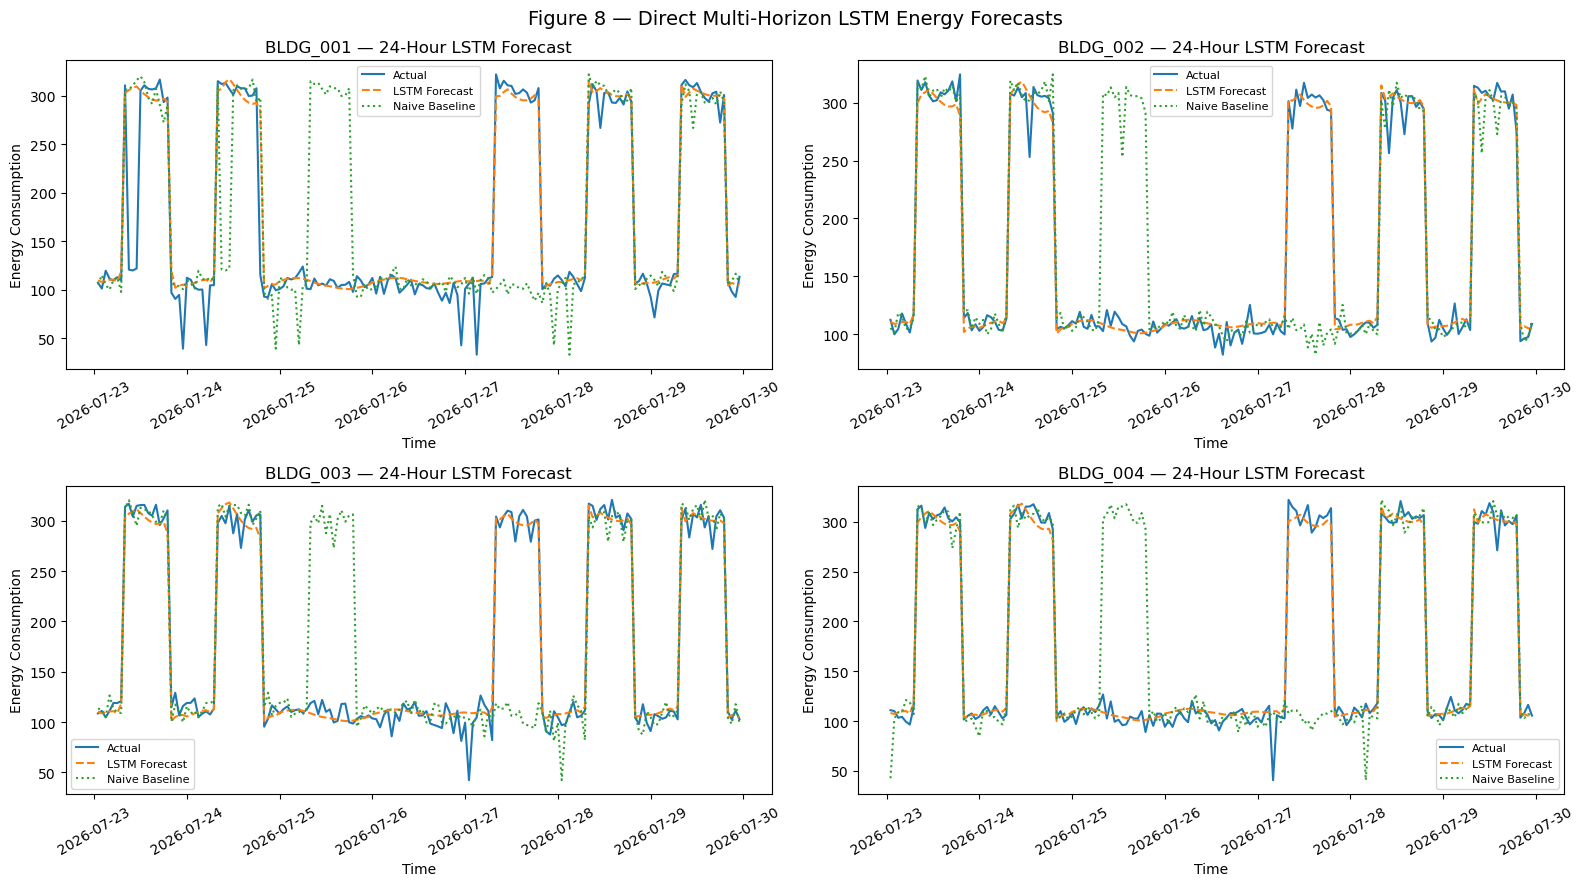

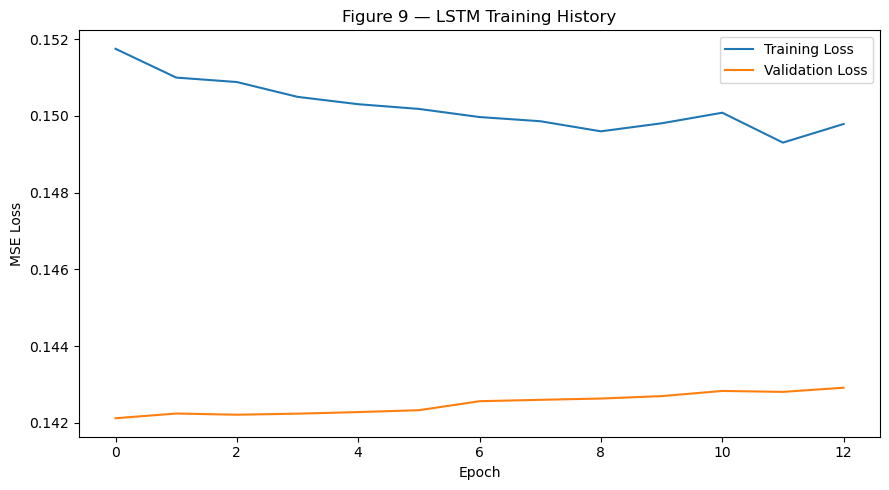

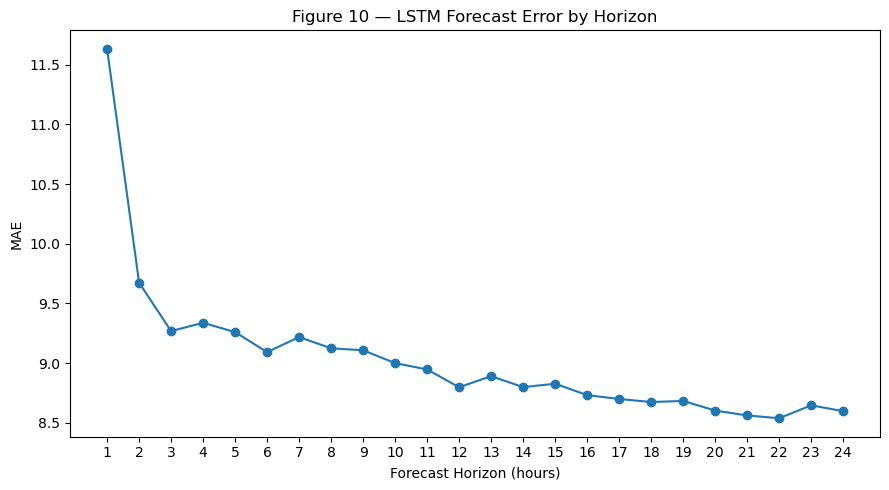


TASK 3 COMPLETED

Model:
  Global LSTM

Forecast:
  Direct 24-hour multi-output forecast

Historical window:
  168 hours

Evaluation:
  Final 7 days of forecast origins

Overall metrics:
  MAE  : 9.0303
  RMSE : 17.0536
  MAPE : 7.51%

Naive baseline:
  MAE  : 43.9288
  RMSE : 85.6712
  MAPE : 30.36%

MAE improvement over baseline: 79.44%


In [32]:
%matplotlib inline
# ============================================================
# 20. CREATE FORECAST OUTPUT
# ============================================================

forecast_rows = []

for i, sample_idx in enumerate(test_indices):

    sample = samples[sample_idx]

    building_id = sample[
        "building_id"
    ]

    origin_timestamp = sample[
        "origin_timestamp"
    ]

    for h in range(FORECAST_HORIZON):

        forecast_timestamp = (
            origin_timestamp
            + pd.Timedelta(
                hours=h + 1
            )
        )

        forecast_rows.append({
            "building_id": building_id,
            "forecast_origin": origin_timestamp,
            "target_timestamp": forecast_timestamp,
            "horizon": h + 1,
            "actual": y_test[i, h],
            "forecast": pred[i, h],
            "baseline": baseline_test[i, h]
        })


forecast_df = pd.DataFrame(
    forecast_rows
)


forecast_df.to_csv(
    MODELS / "lstm_24h_forecasts.csv",
    index=False
)


# ============================================================
# 21. FIGURE 8
# ACTUAL VS FORECAST
# ============================================================

print("\nCreating forecast plots...")

buildings = sorted(
    forecast_df["building_id"].unique()
)[:4]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 9)
)

axes = axes.flatten()


for ax, building_id in zip(
    axes,
    buildings
):

    sub = forecast_df[
        forecast_df["building_id"]
        == building_id
    ].copy()

    # Plot only chronological target values
    # from the held-out period
    actual_series = (
        sub
        .groupby("target_timestamp")["actual"]
        .mean()
    )

    forecast_series = (
        sub
        .groupby("target_timestamp")["forecast"]
        .mean()
    )

    baseline_series = (
        sub
        .groupby("target_timestamp")["baseline"]
        .mean()
    )

    ax.plot(
        actual_series.index,
        actual_series.values,
        label="Actual"
    )

    ax.plot(
        forecast_series.index,
        forecast_series.values,
        linestyle="--",
        label="LSTM Forecast"
    )

    ax.plot(
        baseline_series.index,
        baseline_series.values,
        linestyle=":",
        label="Naive Baseline"
    )

    ax.set_title(
        f"{building_id} — 24-Hour LSTM Forecast"
    )

    ax.set_xlabel(
        "Time"
    )

    ax.set_ylabel(
        "Energy Consumption"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    ax.legend(
        fontsize=8
    )


fig.suptitle(
    "Figure 8 — Direct Multi-Horizon LSTM Energy Forecasts",
    fontsize=14
)

fig.tight_layout()

fig.savefig(
    FIG / "fig8_lstm_forecast_actual_vs_pred.png",
    dpi=130,
    bbox_inches="tight"
)
plt.show()

plt.close(fig)


# ============================================================
# 22. FIGURE 9
# TRAINING HISTORY
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    history.history["loss"],
    label="Training Loss"
)

ax.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

ax.set_title(
    "Figure 9 — LSTM Training History"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "MSE Loss"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    FIG / "fig9_lstm_training_history.png",
    dpi=130,
    bbox_inches="tight"
)
plt.show()

plt.close(fig)


# ============================================================
# 23. FIGURE 10
# FORECAST ERROR BY HORIZON
# ============================================================

horizon_mae = []

for h in range(FORECAST_HORIZON):

    h_mae = mean_absolute_error(
        y_test[:, h],
        pred[:, h]
    )

    horizon_mae.append(
        h_mae
    )


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.plot(
    range(1, FORECAST_HORIZON + 1),
    horizon_mae,
    marker="o"
)

ax.set_title(
    "Figure 10 — LSTM Forecast Error by Horizon"
)

ax.set_xlabel(
    "Forecast Horizon (hours)"
)

ax.set_ylabel(
    "MAE"
)

ax.set_xticks(
    range(1, FORECAST_HORIZON + 1)
)

fig.tight_layout()

fig.savefig(
    FIG / "fig10_lstm_forecast_error.png",
    dpi=130,
    bbox_inches="tight"
)
plt.show()

plt.close(fig)


# ============================================================
# 24. BUILDING-LEVEL METRICS
# ============================================================

building_metrics = []

for building_id in sorted(
    forecast_df["building_id"].unique()
):

    sub = forecast_df[
        forecast_df["building_id"]
        == building_id
    ]

    actual = sub["actual"].to_numpy()
    prediction = sub["forecast"].to_numpy()

    b_mae = mean_absolute_error(
        actual,
        prediction
    )

    b_rmse = np.sqrt(
        mean_squared_error(
            actual,
            prediction
        )
    )

    b_mape = (
        np.mean(
            np.abs(
                (actual - prediction)
                /
                np.maximum(
                    np.abs(actual),
                    1e-3
                )
            )
        )
        * 100
    )

    building_metrics.append({
        "building_id": building_id,
        "MAE": float(b_mae),
        "RMSE": float(b_rmse),
        "MAPE_pct": float(b_mape)
    })


building_metrics_df = pd.DataFrame(
    building_metrics
)

building_metrics_df.to_csv(
    MODELS / "lstm_building_metrics.csv",
    index=False
)


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TASK 3 COMPLETED")
print("=" * 70)

print("\nModel:")
print("  Global LSTM")

print("\nForecast:")
print("  Direct 24-hour multi-output forecast")

print("\nHistorical window:")
print(f"  {HISTORY_HOURS} hours")

print("\nEvaluation:")
print(f"  Final {TEST_DAYS} days of forecast origins")

print("\nOverall metrics:")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAPE : {mape:.2f}%")

print("\nNaive baseline:")
print(f"  MAE  : {baseline_mae:.4f}")
print(f"  RMSE : {baseline_rmse:.4f}")
print(f"  MAPE : {baseline_mape:.2f}%")

print(
    f"\nMAE improvement over baseline: "
    f"{mae_improvement:.2f}%"
)


Healthy training curve (no overfitting, no underfitting)
Validation loss stabilized early
Early stopping prevented unnecessary epochs
Learning rate scheduler adapted when needed
Ready for production forecasting